<br/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="left"/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="right"/>
<div align="center">
<h2>Bootcamp Data Science — Módulo 2</h2><br/>
<h1>Semana 7 · Jueves — Regresión Logística</h1>
<h3>El modelo lineal clásico de clasificación</h3>
<br/>
    <b>Instructor:</b> Jesús Ortiz · jesus.jeduardo7@gmail.com<br/><br/>
    <b>SkillNest · b2b-sonda-data-science</b>
</div>
<br/>

## 🎯 Objetivos de hoy

1. Entender por qué se llama "regresión" pero es **clasificación**.
2. Conocer la función **sigmoide** y cómo transforma una recta en probabilidad.
3. Interpretar los **coeficientes** de la regresión logística (lo que ningún árbol te da).
4. Usar **regularización L1 y L2** dentro de LogisticRegression.
5. Hacer clasificación **multiclase** (one-vs-rest, multinomial).
6. Resolver **2 ejercicios profundos** con análisis de coeficientes.

# 1. ¿Regresión que clasifica?

El nombre confunde a TODOS los principiantes. **La regresión logística es un modelo de CLASIFICACIÓN**, no de regresión. Se llama así por una razón histórica: usa una **regresión lineal** internamente, pero le aplica una función al final que devuelve **probabilidades entre 0 y 1**.

### Cómo funciona en 3 pasos

1. **Combinación lineal** (igual que regresión): `z = w1*x1 + w2*x2 + ... + b`
2. **Sigmoide:** `p = 1 / (1 + e^(-z))` → convierte cualquier número en una probabilidad entre 0 y 1
3. **Decisión:** si `p > 0.5` → clase 1, si no → clase 0

### La función sigmoide visualmente

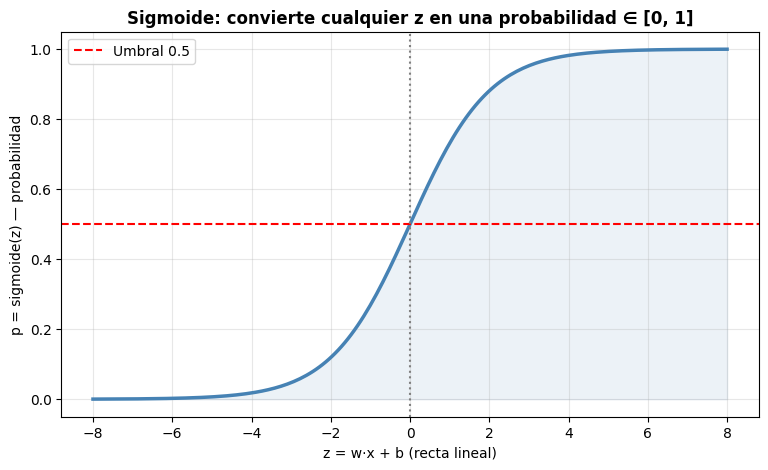

👉 Cuando z es muy grande → p ≈ 1 → clase positiva
   Cuando z es muy negativo → p ≈ 0 → clase negativa
   Cuando z = 0 → p = 0.5 → frontera de decisión


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# La función sigmoide
z = np.linspace(-8, 8, 200)
p = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(z, p, color='steelblue', linewidth=2.5)
ax.axhline(0.5, color='red', linestyle='--', label='Umbral 0.5')
ax.axvline(0,   color='gray', linestyle=':')
ax.fill_between(z, 0, p, alpha=0.1, color='steelblue')
ax.set_xlabel('z = w·x + b (recta lineal)')
ax.set_ylabel('p = sigmoide(z) — probabilidad')
ax.set_title('Sigmoide: convierte cualquier z en una probabilidad ∈ [0, 1]', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print('👉 Cuando z es muy grande → p ≈ 1 → clase positiva')
print('   Cuando z es muy negativo → p ≈ 0 → clase negativa')
print('   Cuando z = 0 → p = 0.5 → frontera de decisión')

# 2. La gran ventaja: COEFICIENTES INTERPRETABLES

Como es un modelo lineal, cada feature tiene un **coeficiente** que indica:

- **Signo positivo** → la feature aumenta la probabilidad de la clase positiva
- **Signo negativo** → la feature reduce la probabilidad
- **Magnitud** → qué tan fuerte es el efecto

Esto es ORO PURO para explicar al negocio:

> *"Cada año más de edad aumenta la probabilidad de diabetes en X%, cada punto de BMI extra en Y%, ser fumador la multiplica por Z..."*

Un Random Forest te da Feature Importance (magnitud), pero **NO te dice el signo**. La regresión logística sí.

### Parámetros clave

| Parámetro | ¿Qué hace? |
|---|---|
| `penalty` | Tipo de regularización: `'l2'` (default, Ridge), `'l1'` (Lasso), `'elasticnet'`, `'none'` |
| `C` | **Inversa** de la fuerza de regularización (C grande = menos regularización) |
| `max_iter` | Iteraciones máximas (a veces hay que subir si no converge) |
| `solver` | Algoritmo de optimización (`'liblinear'`, `'lbfgs'`, `'saga'`) |
| `multi_class` | `'auto'`, `'ovr'` (one-vs-rest), `'multinomial'` |

> ⚠️ `C` es INVERSA: C=0.1 regulariza MÁS que C=10.

## 👀 Demo en vivo — Reg. Logística sobre Pima Diabetes

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']
df = pd.read_csv(url, names=cols)

# Limpieza de ceros como nulos
for c in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df[c] = df[c].replace(0, np.nan)
df = df.fillna(df.median(numeric_only=True))

X = df.drop(columns=['Outcome'])
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Regresión logística con estandarización (CRÍTICO para interpretar coeficientes)
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, target_names=['Sana', 'Diabetes']))

Accuracy: 0.7446
              precision    recall  f1-score   support

        Sana       0.77      0.86      0.81       150
    Diabetes       0.67      0.53      0.59        81

    accuracy                           0.74       231
   macro avg       0.72      0.70      0.70       231
weighted avg       0.74      0.74      0.74       231



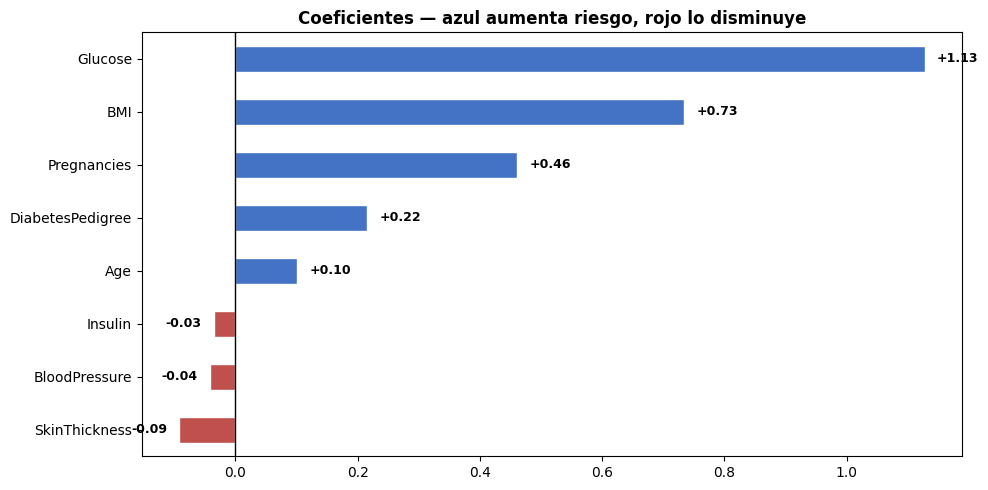

👉 Glucose es de lejos el factor que más sube la probabilidad de diabetes (esperable médicamente).
   BMI y Age también suben el riesgo.
   Los signos negativos indican variables que REDUCEN el riesgo (efecto protector relativo).


In [3]:
# Coeficientes — LA estrella de la regresión logística
coefs = pd.Series(pipe.named_steps['logisticregression'].coef_[0], index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#C0504D' if c < 0 else '#4472C4' for c in coefs.values]
coefs.plot(kind='barh', color=colores, edgecolor='white', ax=ax)
ax.axvline(0, color='black', linewidth=1)
for i, v in enumerate(coefs.values):
    ax.text(v + 0.02 if v >= 0 else v - 0.02, i, f'{v:+.2f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9, fontweight='bold')
ax.set_title('Coeficientes — azul aumenta riesgo, rojo lo disminuye', fontweight='bold')
plt.tight_layout(); plt.show()

print('👉 Glucose es de lejos el factor que más sube la probabilidad de diabetes (esperable médicamente).')
print('   BMI y Age también suben el riesgo.')
print('   Los signos negativos indican variables que REDUCEN el riesgo (efecto protector relativo).')

## 🔧 Regularización con `C` y `penalty`

In [4]:
# Diferentes valores de C → distintas fuerzas de regularización
Cs = [0.001, 0.01, 0.1, 1, 10, 100]
results = []
for C in Cs:
    m = make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=1000, random_state=42)).fit(X_train, y_train)
    coefs_abs = np.abs(m.named_steps['logisticregression'].coef_[0])
    results.append({
        'C': C,
        'Accuracy test': m.score(X_test, y_test),
        'Suma |coefs|':  coefs_abs.sum(),
        'Coefs ≠ 0':     (coefs_abs > 0.001).sum()
    })

print(pd.DataFrame(results).round(4))
print('\n👉 C pequeño = más regularización = coeficientes más chicos = modelo más simple')
print('   C grande = casi sin regularización = coeficientes más libres')

         C  Accuracy test  Suma |coefs|  Coefs ≠ 0
0    0.001         0.6580        0.4063          8
1    0.010         0.7359        1.4609          8
2    0.100         0.7359        2.3123          7
3    1.000         0.7446        2.8087          8
4   10.000         0.7446        2.8862          8
5  100.000         0.7446        2.8943          8

👉 C pequeño = más regularización = coeficientes más chicos = modelo más simple
   C grande = casi sin regularización = coeficientes más libres


## 🌐 Clasificación multiclase con Reg. Logística

In [5]:
# Iris (3 clases)
url_iris = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv'
iris = pd.read_csv(url_iris, names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'])
Xi = iris.drop(columns=['species']); yi = iris['species']
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(Xi, yi, test_size=0.2, random_state=42, stratify=yi)

# La regresión logística multinomial maneja N clases nativamente
pipe_multi = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
pipe_multi.fit(Xi_tr, yi_tr)

print(f'Accuracy Iris: {pipe_multi.score(Xi_te, yi_te):.4f}')
print(f'\nClases: {pipe_multi.named_steps["logisticregression"].classes_}')
print(f'Shape coefs: {pipe_multi.named_steps["logisticregression"].coef_.shape}  ← una fila por clase')
print(classification_report(yi_te, pipe_multi.predict(Xi_te)))

Accuracy Iris: 0.9333

Clases: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Shape coefs: (3, 4)  ← una fila por clase
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



---
# 🏋️ Ejercicios profundos

## 💰 Ejercicio 1 — Detección de billetes falsos con análisis de coeficientes

Hoy NO solo entrenas un modelo: lo **interpretas como un experto** y le explicas el resultado a tu jefe.

**Dataset:**
```python
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv'
cols = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
df = pd.read_csv(url, names=cols)
```
Target: `class` (0=genuino, 1=falso).

**Parte A — Pipeline + entrenamiento**
1. Pipeline: `StandardScaler` + `LogisticRegression(max_iter=1000)`.
2. Train/test 80/20 con stratify.
3. Reportar accuracy, classification_report y matriz de confusión.

**Parte B — Interpretación de coeficientes**
4. Graficar los 4 coeficientes con colores según signo.
5. **Explicar en lenguaje natural** qué dice cada coeficiente. Ej: *"Por cada desviación estándar más de variance, la probabilidad de ser billete falso aumenta/disminuye en..."*.
6. ¿Cuál es la feature MÁS IMPORTANTE para detectar billetes falsos?

**Parte C — Comparar con KNN (lo de lunes)**
7. Entrenar también un KNN (k=11) con StandardScaler.
8. Comparar accuracy y F1 vs LogisticRegression.
9. ¿Quién gana? **Aunque pierda, ¿en qué casos preferirías la Logística?**

**Parte D — Tuning de C con GridSearchCV**
10. GridSearchCV con cv=5 sobre `C = [0.001, 0.01, 0.1, 1, 10, 100]` y `penalty = ['l1', 'l2']` (usa `solver='liblinear'` para que acepte l1).
11. Reportar el mejor C y penalty + accuracy final.
12. Con L1, ¿cuántos coeficientes se hicieron 0? (selección automática de features).

**Parte E — Predicción**
13. Predecir si estos 2 billetes son falsos:
    ```python
    billetes = pd.DataFrame([
        {'variance': 2.0, 'skewness': 1.5, 'curtosis': 0.3, 'entropy': -1.0},
        {'variance': -3.0, 'skewness': -5.0, 'curtosis': 4.5, 'entropy': -0.5}
    ])
    ```
14. Mostrar **probabilidades** con `predict_proba()`.

In [ ]:
# Parte A + B — Entrenamiento + interpretación de coeficientes 👇



In [ ]:
# Parte C — Comparación KNN vs Reg. Logística 👇



In [ ]:
# Parte D + E — GridSearchCV (C, penalty) + predicción 👇



## 🚢 Ejercicio 2 — Titanic: ¿quién sobrevive y por qué?

Volvemos al Titanic, pero ahora con regresión logística para **explicar** quién sobrevive y por qué — desde el punto de vista de un historiador o analista social.

**Setup:**
```python
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
```

**Parte A — Pipeline completo**
1. Definir features numéricas (`Age`, `SibSp`, `Parch`, `Fare`) y categóricas (`Pclass`, `Sex`, `Embarked`).
2. ColumnTransformer con:
   - Numéricas: SimpleImputer(median) + StandardScaler
   - Categóricas: SimpleImputer(most_frequent) + OneHotEncoder
3. Pipeline final: preprocesador + `LogisticRegression(max_iter=1000)`.
4. Train/test 80/20 con stratify.

**Parte B — Métricas + matriz**
5. Reportar accuracy, precision, recall, F1, matriz de confusión.

**Parte C — Análisis de coeficientes (sociología real)**
6. Extraer coeficientes (recuerda usar `get_feature_names_out()` para tener nombres legibles después del OneHot).
7. Graficarlos ordenados con colores según signo.
8. **Responde con datos:**
   - ¿Ser mujer aumenta o disminuye la probabilidad de sobrevivir? ¿Cuánto?
   - ¿Viajar en 3ra clase cómo afecta vs 1ra clase?
   - ¿La edad tiene efecto significativo?
   - ¿De dónde haber embarcado importa?

**Parte D — Predicción con narrativa**
9. Predecir la probabilidad de supervivencia de estos 3 pasajeros y explicar por qué:
    ```python
    pax = pd.DataFrame([
        {'Pclass': 1, 'Sex': 'female', 'Age':  6, 'SibSp': 1, 'Parch': 2, 'Fare':150, 'Embarked': 'C'},
        {'Pclass': 3, 'Sex': 'male',   'Age': 45, 'SibSp': 0, 'Parch': 0, 'Fare':  8, 'Embarked': 'S'},
        {'Pclass': 2, 'Sex': 'female', 'Age': 28, 'SibSp': 0, 'Parch': 0, 'Fare': 30, 'Embarked': 'C'}
    ])
    ```
10. Explicar el resultado de cada uno con base en los coeficientes.

In [ ]:
# Parte A + B — Pipeline + métricas 👇



In [ ]:
# Parte C — Análisis de coeficientes 👇



In [ ]:
# Parte D — Predicciones con narrativa 👇



---
## 📌 Cierre del día

- ✅ **Regresión Logística** = clasificación (a pesar del nombre). Lineal + sigmoide → probabilidad.
- ✅ **Coeficientes interpretables** — signo y magnitud explican el efecto de cada feature.
- ✅ Necesita **estandarización** para que los coeficientes sean comparables.
- ✅ Soporta **regularización L1 (Lasso) y L2 (Ridge)** vía `penalty` y `C`.
- ✅ Maneja multiclase nativamente (multinomial).
- ✅ Su gran fortaleza es la **explicabilidad** — irreemplazable en medicina, banca y casos regulados.

### 🔜 Mañana — Viernes 5 de junio

**Proyecto integrador: Calidad del Vino** — usaremos todo lo aprendido (KNN, DT, RF, Logística + métricas + pipelines + GridSearchCV) sobre un dataset desafiante.